<a href="https://colab.research.google.com/github/wtryab-re/whats-your-eda-basics/blob/main/univariate_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Univariate Analysis -- checks the features and target one by one.
Checks of Central Measures

Checks of Dispersion

Checks of Skewness

Checks of Kurtosis

Categorical - frequency, countplots

#Installation and Imports

In [1]:
!pip install -q seaborn matplotlib pandas numpy scikit-learn

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [21]:
np.random.seed(42)
sns.set_style("whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns",None)

In [22]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


In [23]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [25]:
df.shape

(891, 15)

In [ ]:
###Firstly we gotta see which are categorical features because some features are written in numerics but they actually represent categories.
##So separate them

In [38]:
numeric_cols = [ 'age', 'sibsp', 'parch', 'fare']
categorical_cols = ['survived',"pclass", 'sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

#Numerical Columns Analysis

Checks of Dispersion -- Std, variance

Checks of Skewness -- skew

Checks of Kurtosis -- Kurtosis is a statistical measure that describes the "tailedness" of a probability distribution, indicating the frequency and extremity of outliers

In [97]:
x = df[numeric_cols].describe().T
x["skew"]= df[numeric_cols].skew()
x["variance"]= df[numeric_cols].var()
x["kurtosis"]= df[numeric_cols].kurtosis()
x["range"]= df[numeric_cols].max()-df[numeric_cols].min()
x["mode"] = df[numeric_cols].mode().T
x

,count,mean,std,min,25%,50%,75%,max,skew,variance,kurtosis,range,mode
age,714.00,29.70,14.53,0.42,20.12,28.00,38.00,80.00,0.39,211.02,0.18,79.58,24.00
sibsp,891.00,0.52,1.10,0.00,0.00,0.00,1.00,8.00,3.70,1.22,17.88,8.00,0.00
parch,891.00,0.38,0.81,0.00,0.00,0.00,0.00,6.00,2.75,0.65,9.78,6.00,0.00
fare,891.00,32.20,49.69,0.00,7.91,14.45,31.00,512.33,4.79,2469.44,33.40,512.33,8.05


#Histograms and Pairplots and Boxplots

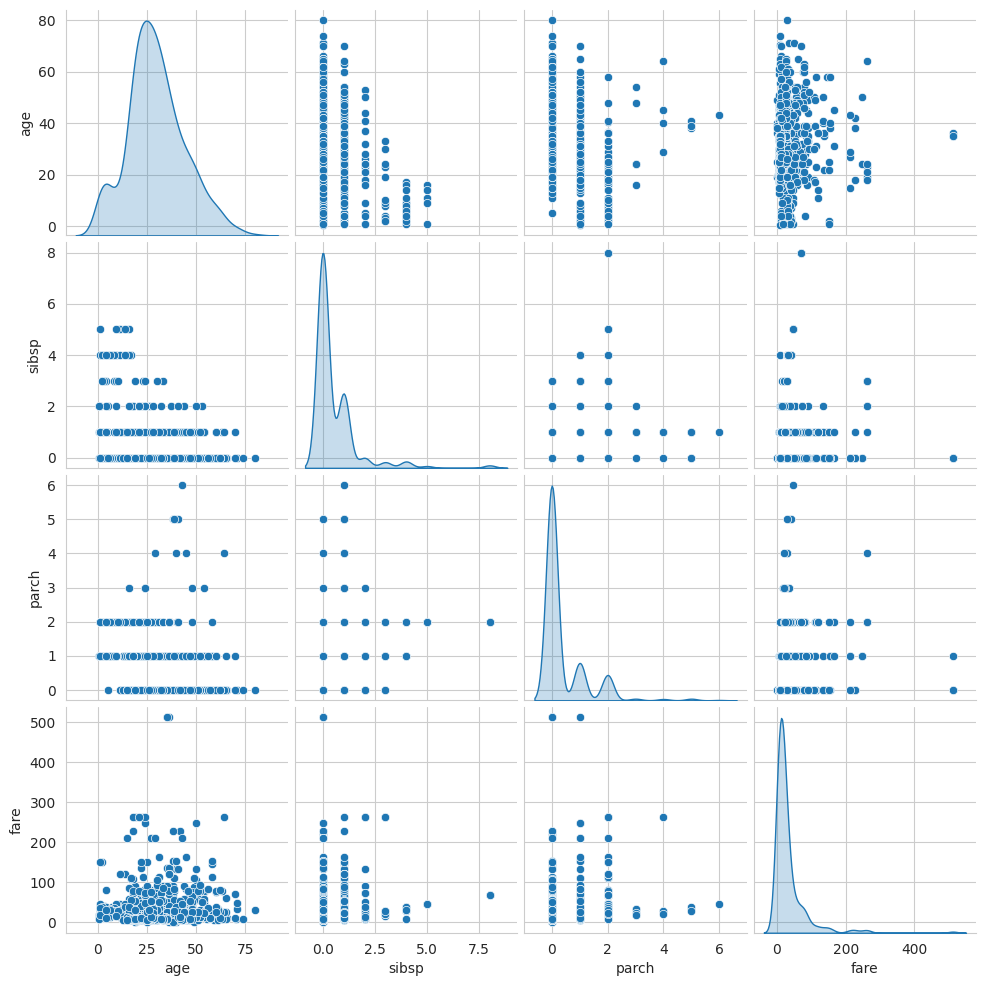

In [104]:
sns.pairplot(df[numeric_cols], diag_kind="kde")

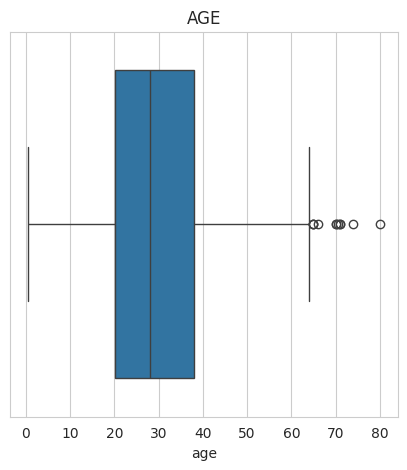

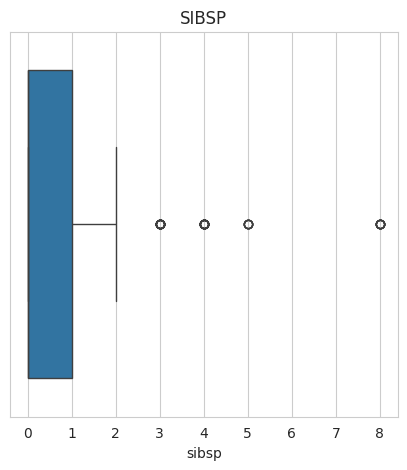

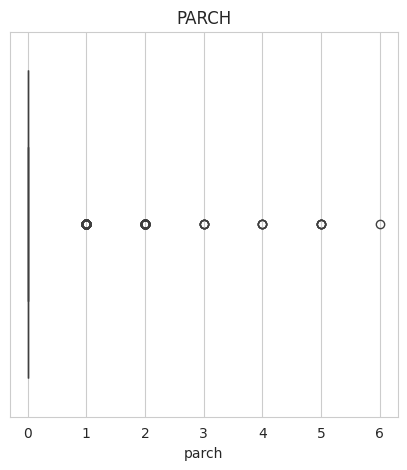

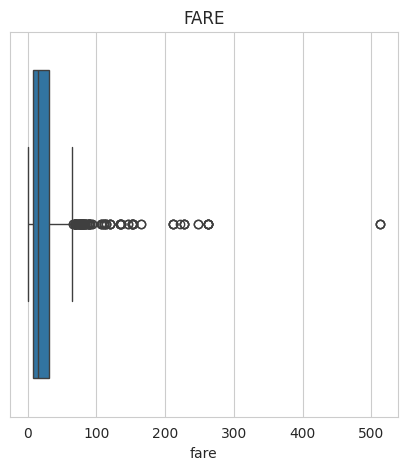

In [147]:
for col in numeric_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(df[col], orient="h")
  plt.title(col.upper())
  plt.show()

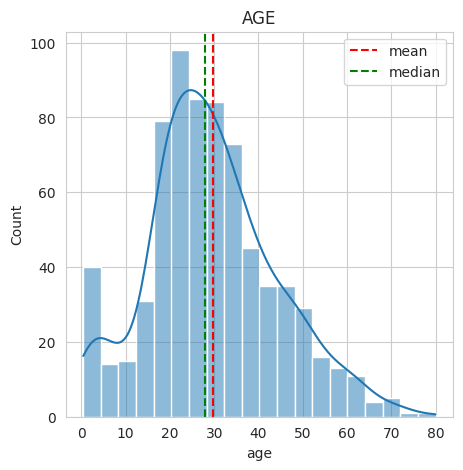

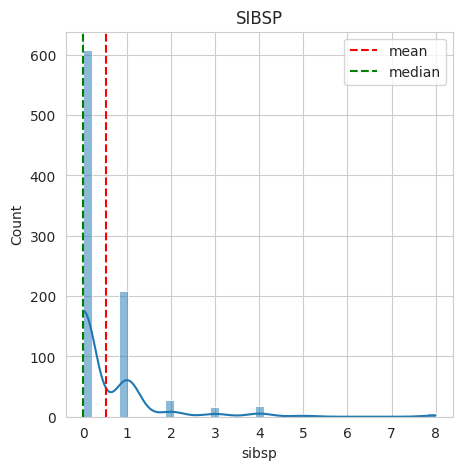

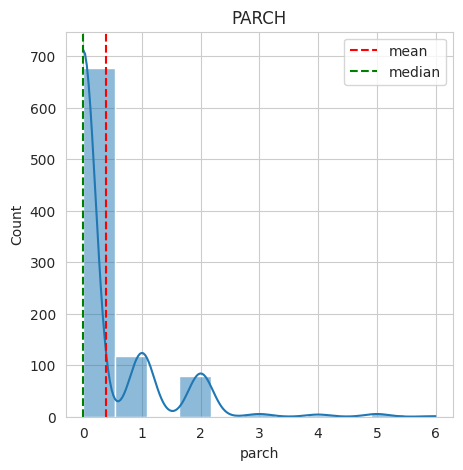

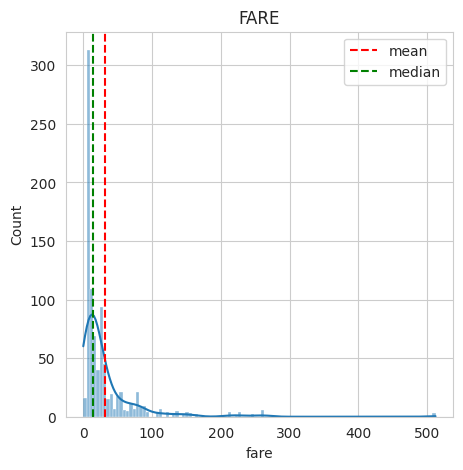

In [139]:
for col in numeric_cols:
  plt.figure(figsize=(5,5))
  sns.histplot(df[col], kde=True)
  plt.axvline(df[col].mean(), color="red", linestyle="--", label="mean")
  plt.axvline(df[col].median(), color="green", linestyle="--", label="median")
  plt.title(col.upper())
  plt.legend()
  plt.show()

#Categorical Features

In [151]:
df[categorical_cols].head()

,survived,pclass,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,S,Third,man,True,NaN,Southampton,no,True


In [162]:
for col in categorical_cols:
  print(col.upper(), "FREQUENCY")
  print(df[col].value_counts())
  print(col.upper(), "Proportion")
  print(df[col].value_counts(normalize=True))
  print("-"*50)

SURVIVED FREQUENCY
survived
0    549
1    342
Name: count, dtype: int64
SURVIVED Proportion
survived
0   0.62
1   0.38
Name: proportion, dtype: float64
--------------------------------------------------
PCLASS FREQUENCY
pclass
3    491
1    216
2    184
Name: count, dtype: int64
PCLASS Proportion
pclass
3   0.55
1   0.24
2   0.21
Name: proportion, dtype: float64
--------------------------------------------------
SEX FREQUENCY
sex
male      577
female    314
Name: count, dtype: int64
SEX Proportion
sex
male     0.65
female   0.35
Name: proportion, dtype: float64
--------------------------------------------------
EMBARKED FREQUENCY
embarked
S    644
C    168
Q     77
Name: count, dtype: int64
EMBARKED Proportion
embarked
S   0.72
C   0.19
Q   0.09
Name: proportion, dtype: float64
--------------------------------------------------
CLASS FREQUENCY
class
Third     491
First     216
Second    184
Name: count, dtype: int64
CLASS Proportion
class
Third    0.55
First    0.24
Second   0.21
Name:

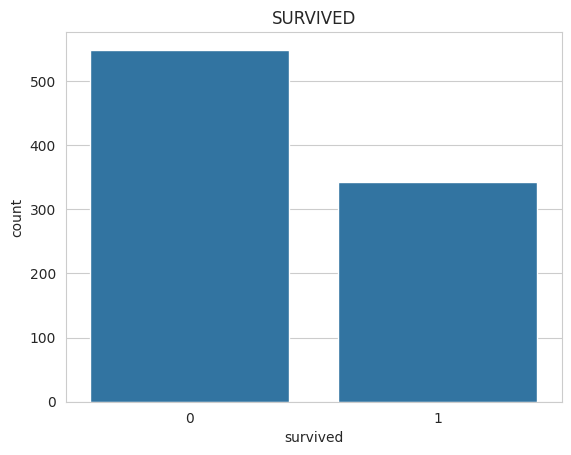

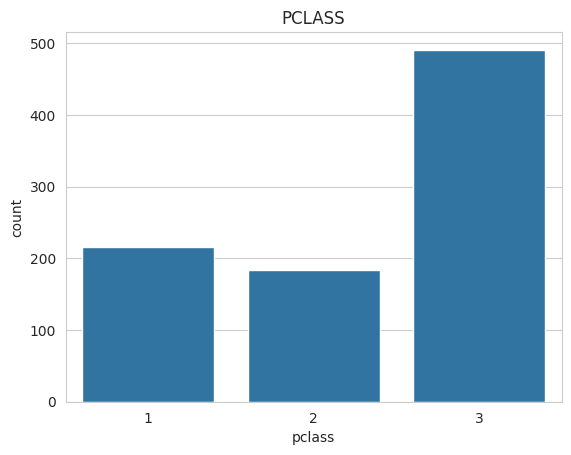

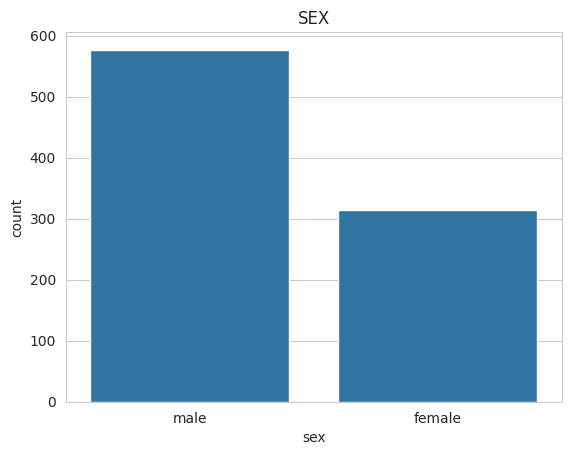

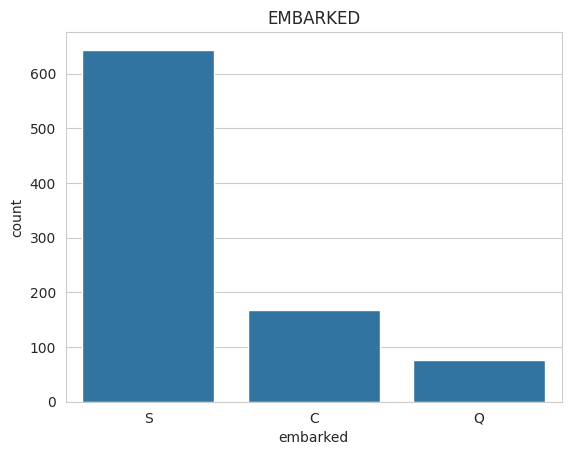

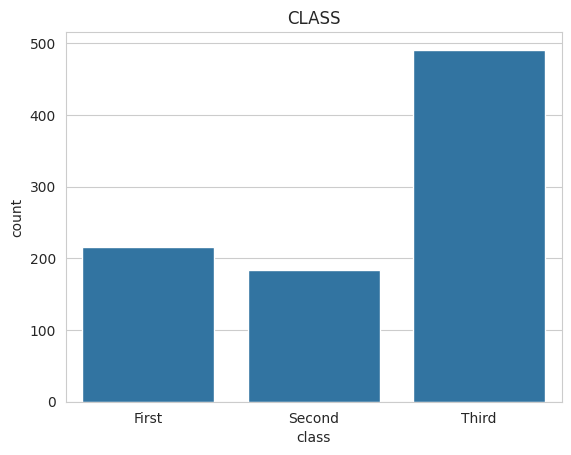

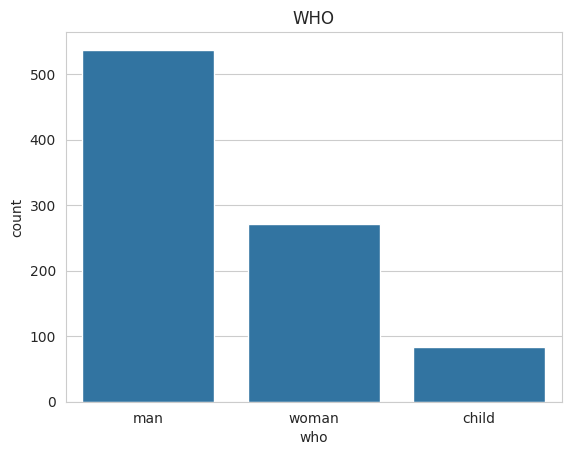

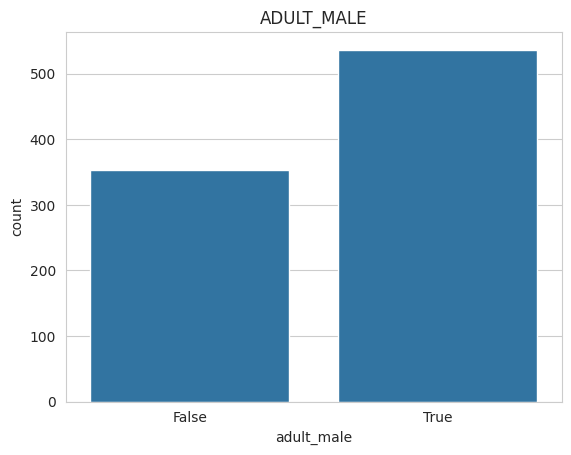

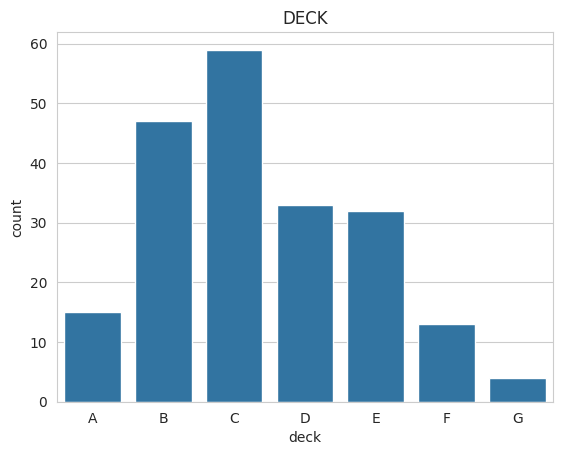

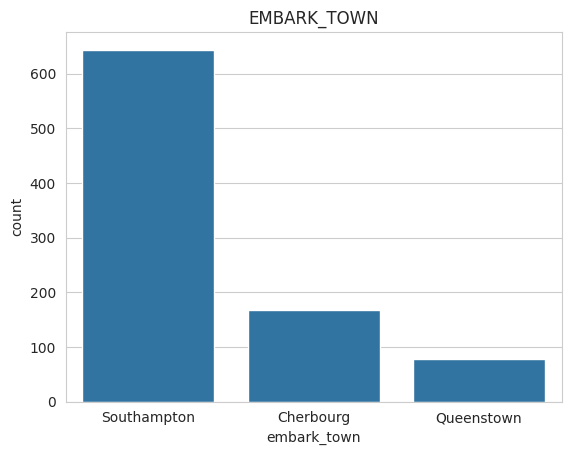

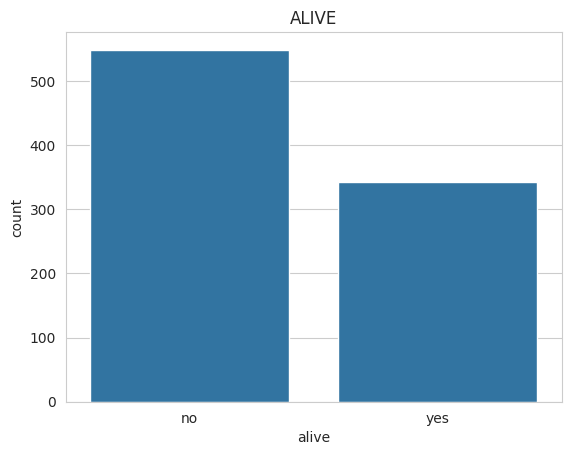

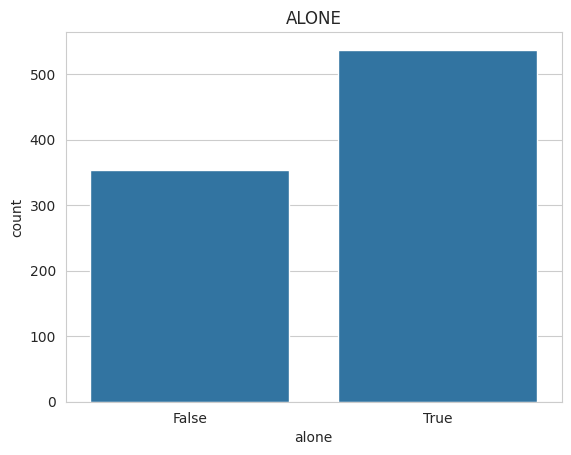

In [167]:
for col in categorical_cols:
  sns.countplot(x =df[col])
  plt.title(col.upper())
  plt.show()